# Unemployment clustering (country profiles)

[Kaggle dataset: lucalullo/global-employment-unemployment-rates-1991-2025](https://www.kaggle.com/datasets/lucalullo/global-employment-unemployment-rates-1991-2025)

Unsupervised grouping of countries by **unemployment rate trajectories** (`Total`, `15+`), in the spirit of exploratory clustering notebooks (e.g. [penguins clustering EDA](https://www.kaggle.com/code/nicapotato/clustering-penguins-species-eda)). Clusters are **not** causal labels—only a compact summary of multi-year patterns.


## Setup & load

In [1]:
import os
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, HTML
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

PRISM = list(px.colors.qualitative.Prism)
px.defaults.color_discrete_sequence = PRISM
px.defaults.color_continuous_scale = [[i / max(len(PRISM) - 1, 1), c] for i, c in enumerate(PRISM)]
px.defaults.template = "plotly_white"

_IS_KAGGLE = bool(os.environ.get("KAGGLE_KERNEL_RUN_TYPE")) or Path("/kaggle").exists()
if _IS_KAGGLE:
    pio.renderers.default = "iframe"


def show_plotly(fig):
    fig.update_layout(paper_bgcolor="white", plot_bgcolor="white", colorway=PRISM)
    if os.environ.get("PLOTLY_FORCE_HTML", "").lower() in ("1", "true", "yes"):
        display(HTML(fig.to_html(include_plotlyjs="cdn", full_html=False)))
    elif _IS_KAGGLE:
        fig.show()
    else:
        display(HTML(fig.to_html(include_plotlyjs="cdn", full_html=False)))


def resolve_data_dir() -> Path:
    explicit = Path("/kaggle/input/global-employment-unemployment-rates-1991-2025")
    if explicit.exists():
        return explicit
    base = Path("/kaggle/input")
    if base.exists():
        for p in base.rglob("occupazione.csv"):
            return p.parent
    local = Path("data")
    assert (local / "occupazione.csv").exists() and (local / "disoccupazione.csv").exists(), (
        f"Expected occupazione.csv and disoccupazione.csv under {local.resolve()} — run `make download`"
    )
    return local


def load_employment_frames(data_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    xlsx = sorted(data_dir.glob("*.xlsx")) + sorted(data_dir.glob("*.xls"))
    if xlsx:
        path = xlsx[0]
        emp = pd.read_excel(path, sheet_name="occupazione")
        unemp = pd.read_excel(path, sheet_name="disoccupazione")
    else:
        ocp, disc = data_dir / "occupazione.csv", data_dir / "disoccupazione.csv"
        assert ocp.exists() and disc.exists(), f"Missing CSVs under {data_dir}"
        emp = pd.read_csv(ocp)
        unemp = pd.read_csv(disc)
    for df in (emp, unemp):
        assert set(df.columns) >= {"iso_code", "country", "sex", "age", "year", "obs_value"}
    return emp, unemp


DATA_DIR = resolve_data_dir()
print(f"DATA_DIR = {DATA_DIR}")
df_emp, df_unemp = load_employment_frames(DATA_DIR)


DATA_DIR = data


## Panel → country × year matrix

Filter **unemployment** to `sex == "Total"` and `age == "15+"`. Pivot so each row is a country and columns are years. Drop countries missing more than 20% of years; **impute** remaining gaps with the **column (year) median** so KMeans always sees a numeric matrix. Report how many rows were dropped vs how many cells imputed.


In [2]:
BASE_SEX = "Total"
BASE_AGE = "15+"
uv = df_unemp[(df_unemp["sex"] == BASE_SEX) & (df_unemp["age"] == BASE_AGE)].copy()
wide = uv.pivot_table(index="iso_code", columns="year", values="obs_value", aggfunc="first")
years = sorted(wide.columns)
wide = wide[years]
country_map = uv.drop_duplicates("iso_code").set_index("iso_code")["country"]

min_frac = 0.8
thresh = int(np.ceil(min_frac * len(years)))
row_ok = wide.notna().sum(axis=1) >= thresh
dropped = int((~row_ok).sum())
wide_f = wide.loc[row_ok].copy()
print(f"Countries kept: {len(wide_f)} (dropped {dropped} with < {min_frac:.0%} non-null years)")

n_missing_before = wide_f.isna().sum().sum()
col_med = wide_f.median(axis=0, skipna=True)
wide_f = wide_f.fillna(col_med)
n_imputed = int(wide_f.isna().sum().sum())
assert n_imputed == 0
print(f"Cells imputed with year-median: {int(n_missing_before)}")


Countries kept: 183 (dropped 0 with < 80% non-null years)
Cells imputed with year-median: 14


## Feature matrix: scaled years + simple summaries

Per country: all **year columns** (standardized across countries) plus **mean**, **std**, and **OLS slope** of unemployment vs year (numpy `polyfit` on available pre-imputation values — here post-imputation series is complete). `StandardScaler` is fit on the full feature block before KMeans.


In [3]:
def trajectory_slope(row: pd.Series) -> float:
    ys = row.values.astype(float)
    xs = np.asarray(row.index, dtype=float)
    if np.all(np.isnan(ys)):
        return np.nan
    m = np.isfinite(ys)
    if m.sum() < 2:
        return 0.0
    coef = np.polyfit(xs[m], ys[m], 1)
    return float(coef[0])


X_years = wide_f.copy()
X_years.columns = X_years.columns.astype(int)
slopes = X_years.apply(trajectory_slope, axis=1)
feat = X_years.copy()
feat["mean_unemp"] = X_years.mean(axis=1)
feat["std_unemp"] = X_years.std(axis=1)
feat["slope_vs_year"] = slopes.values

feature_names = list(feat.columns)
X = feat.to_numpy(dtype=float)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
iso_list = feat.index.tolist()
print("Features:", len(feature_names), "| samples:", X_scaled.shape[0])


Features: 38 | samples: 183


## KMeans: elbow and silhouette (k = 3 … 8)

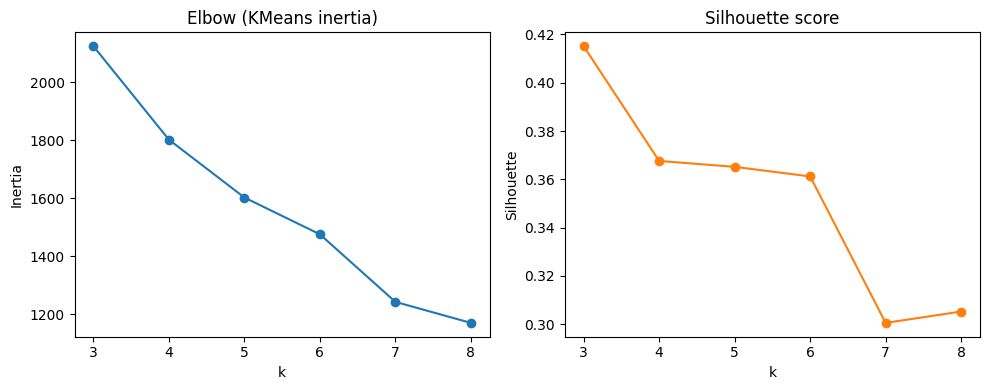

Pick k with max silhouette in grid: k = 3


In [4]:
K_MIN, K_MAX = 3, 8
ks = list(range(K_MIN, K_MAX + 1))
inertias = []
silhouettes = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = (
        silhouette_score(X_scaled, labels)
        if k >= 2 and len(np.unique(labels)) > 1
        else np.nan
    )
    silhouettes.append(sil)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(ks, inertias, marker="o")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertia")
ax[0].set_title("Elbow (KMeans inertia)")
ax[1].plot(ks, silhouettes, marker="o", color="C1")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Silhouette")
ax[1].set_title("Silhouette score")
plt.tight_layout()
plt.show()

best_k = int(ks[int(np.nanargmax(silhouettes))])
print(f"Pick k with max silhouette in grid: k = {best_k}")
K_STAR = best_k


## PCA 2D embedding + cluster assignment

In [5]:
km_final = KMeans(n_clusters=K_STAR, random_state=42, n_init="auto")
cluster_labels = km_final.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=42)
XY = pca.fit_transform(X_scaled)
pc_df = pd.DataFrame(
    {
        "PC1": XY[:, 0],
        "PC2": XY[:, 1],
        "cluster": cluster_labels.astype(str),
        "iso_code": iso_list,
        "country": [country_map.get(i, i) for i in iso_list],
    }
)
fig = px.scatter(
    pc_df,
    x="PC1",
    y="PC2",
    color="cluster",
    hover_data=["country", "iso_code"],
    title=f"PCA of unemployment features — KMeans k={K_STAR}",
)
show_plotly(fig)
print("Explained variance ratio:", pca.explained_variance_ratio_)


Explained variance ratio: [0.81038036 0.09300276]


## Mean unemployment trajectory by cluster

In [6]:
wide_c = wide_f.reset_index(names="iso_code").copy()
wide_c["cluster"] = cluster_labels
wide_c["country"] = wide_c["iso_code"].map(country_map)
long = wide_c.melt(
    id_vars=["iso_code", "country", "cluster"],
    var_name="year",
    value_name="unemployment",
)
prof = long.groupby(["cluster", "year"], as_index=False)["unemployment"].mean()
prof["cluster_str"] = prof["cluster"].astype(str)
fig = px.line(
    prof,
    x="year",
    y="unemployment",
    color="cluster_str",
    markers=False,
    title="Mean unemployment (Total, 15+) by cluster",
)
fig.update_layout(hovermode="x unified")
show_plotly(fig)


## Interpretation (qualitative)

- **High / persistent**: clusters with elevated mean unemployment across most years.
- **Improving / declining rate**: negative slope vs year in the feature block (check `slope_vs_year` means by cluster if needed).
- **Volatile**: higher `std_unemp` relative to other clusters.

These names are **descriptive only**; policy or macro conclusions need external theory and identification.
